# **Spotify Trends EDA (2014–2020)**

In [ ]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# loading dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/spotify_2014_2020_dataset.csv")

In [ ]:
# checking the attributes of the dataset
df.head()

,Track_ID,Track_Name,Duration_Min,Artists,Release_Date,Year,Query
0,6dBUzqjtbnIa1TwYbyw5CM,Lovers Rock,3.57,TV Girl,6/5/2014,2014,love
1,5J4ZkQpzMUFojo1CtAZYpn,Love Me Harder,3.94,"Ariana Grande, The Weeknd",8/22/2014,2014,love
2,2e3Ea0o24lReQFR4FA7yXH,Love Yourz,3.52,J. Cole,12/9/2014,2014,love
3,6nGeLlakfzlBcFdZXteDq7,Love Story,5.27,Indila,1/1/2014,2014,love
4,5BJSZocnCeSNeYMj3iVqM7,Love Runs Out,3.74,OneRepublic,1/1/2014,2014,love


In [ ]:
# checking the composition of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Track_ID      1701 non-null   object 
 1   Track_Name    1701 non-null   object 
 2   Duration_Min  1701 non-null   float64
 3   Artists       1701 non-null   object 
 4   Release_Date  1701 non-null   object 
 5   Year          1701 non-null   int64  
 6   Query         1701 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 93.2+ KB


The dataset contains 1,701 entries across 7 columns with no missing values, indicating a clean and complete dataset. In terms of data types, Year is stored as an integer, Duration_Min as a float, and the remaining columns are stored as objects. Release_Date will need to be converted to datetime format later for time-based analysis.

In [ ]:
# checking for null
df.isnull().sum()

,0
Track_ID,0
Track_Name,0
Duration_Min,0
Artists,0
Release_Date,0
Year,0
Query,0


In [ ]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset and the dataset also contains no null values

In [ ]:
# checking for outliers in the duration column
df['Duration_Min'].describe()

,Duration_Min
count,1701.000000
mean,4.268595
std,5.260055
min,3.000000
25%,3.460000
50%,3.830000
75%,4.320000
max,180.470000


From the above data we have actually came across an outlier which is the song that is 180 minutes long

In [ ]:
# removing outlier
df = df[df['Duration_Min']<10]

We have removed all the songs that were more than 10 minutes long initially we had 1,701 rows now we are left with 1,692 rows, meaning we had 9 outliers,removing these 9 outliers prevents extreme values from skewing the mean and scaling of the features

Text(0.5, 1.0, 'Distribution of song duration')

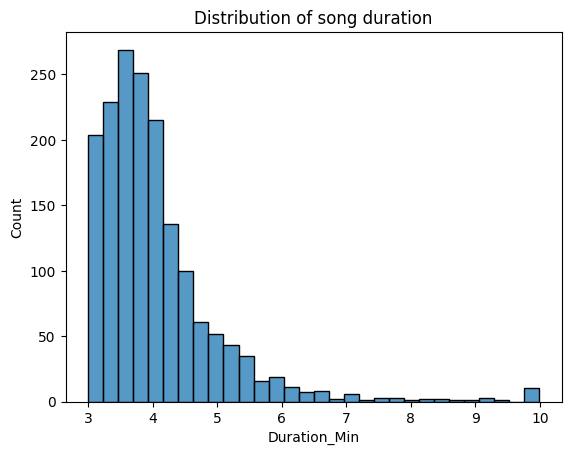

In [ ]:
# Distribution of duration
g1 = sns.histplot(df['Duration_Min'], bins = 30)
g1.set_title('Distribution of song duration')


In [ ]:
df['Duration_Min'].mode()

,Duration_Min
0,3.57


By looking at the histogram we can tell that majority of our songs have a duration between the range of 3 to 4 minutes, and the most number of songs, 250+ have a duration of 3.57

Text(0.5, 1.0, 'Songs per year')

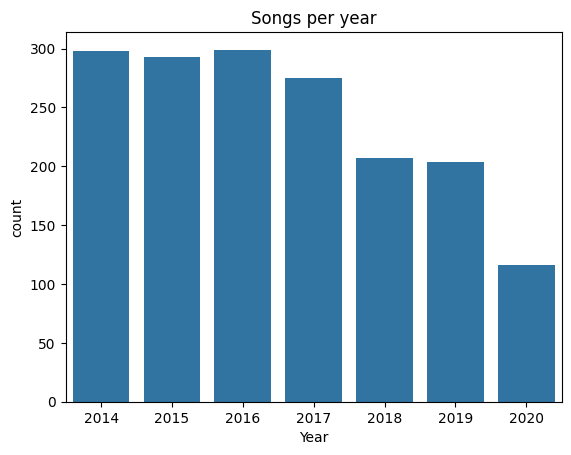

In [ ]:
# track count per year
g2 = sns.barplot(df['Year'].value_counts().sort_index())
g2.set_title('Songs per year')



After 2016 the number of tracks released per year had a visible decline in numbers

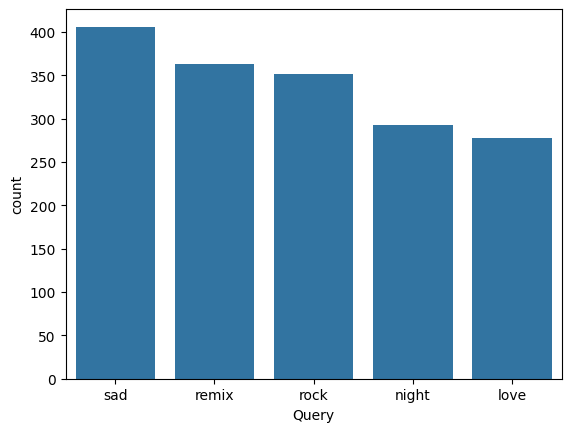

In [ ]:
# song per theme
g3 = sns.barplot(df['Query'].value_counts())

From 2014 to 2020 majority of the tracks that were released belonged to sad query or category

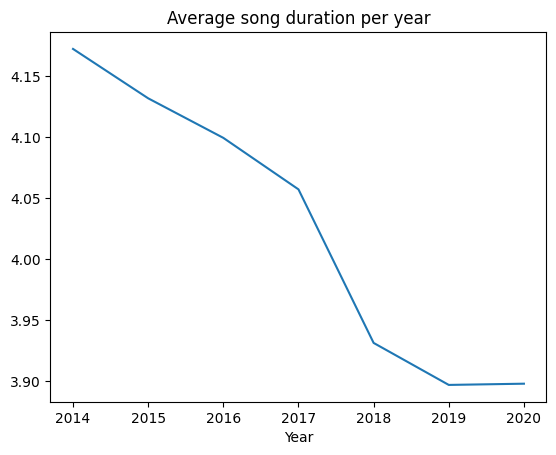

In [ ]:
# Bivariate Analysis

# average duration per year
df.groupby('Year')['Duration_Min'].mean().plot(kind = 'line')
plt.title('Average song duration per year')
plt.show()

With each passing year the duration of songs decreased, suggesting a trend toward shorter tracks in the streaming era

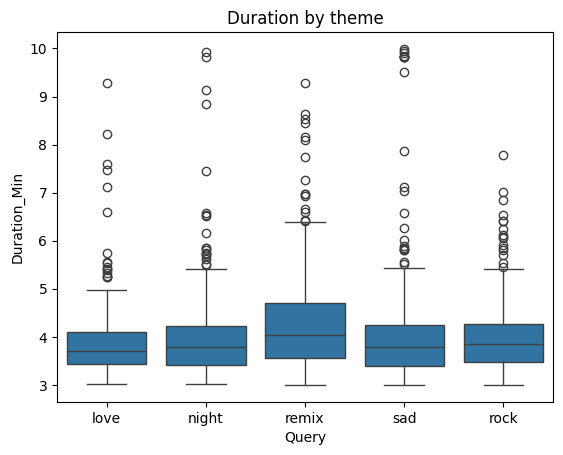

In [ ]:
# Track duration vs category
sns.boxplot(x = 'Query', y = 'Duration_Min',data = df)
plt.title('Duration by theme')
plt.show()

The above graphs shows us that the sad category had the longest tracks on average and as for the lowest, love category had the shortest songs on average

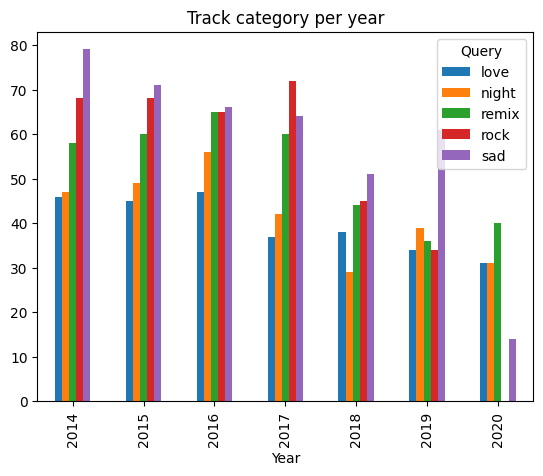

In [ ]:
# Track category vs year
df.groupby(['Year','Query']).size().unstack().plot(kind = 'bar')
plt.title('Track category per year')
plt.show()

This graph suggests that on average sad category has more songs released per year than other category and love category on average has the least number of songs releases per year

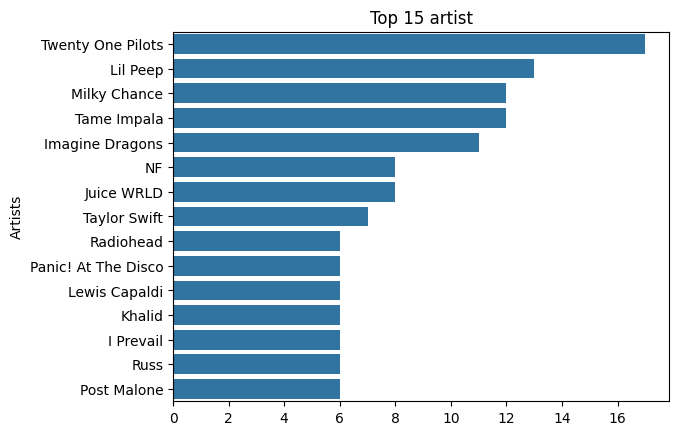

In [27]:
# determining the top artist
top_artist = df['Artists'].value_counts().head(15)
sns.barplot(x = top_artist.values, y = top_artist.index)
plt.title('Top 15 artist')
plt.show()

The above graph shows us that throughout the dataset the most dominant artist was twenty one pilots and the least dominant artist was post malone

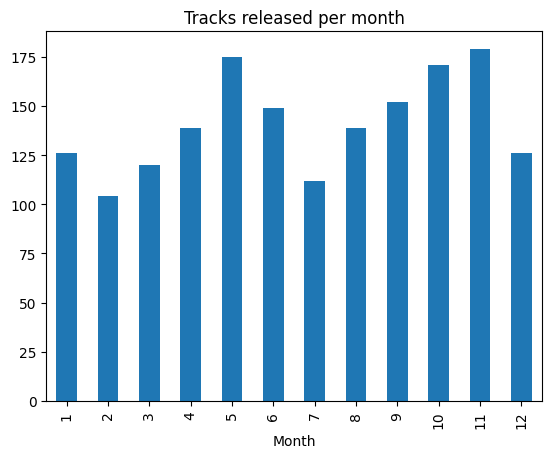

In [33]:
# track release per month
df['Release_Date'] = pd.to_datetime(df['Release_Date'], format='mixed', errors='coerce')
df['Month'] = df['Release_Date'].dt.month
df['Release_Year'] = df['Release_Date'].dt.year

df['Month'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Tracks released per month')
plt.show()


In the month of november more than 175 tracks were released and in feburary only 100+ tracks were released

## **Summary:**

This notebook presents an exploratory data analysis of a Spotify dataset containing 1,701 tracks collected between 2014 and 2020 across five search themes  love, sad, rock, night, and remix. The goal of this analysis is to uncover patterns in song duration, track releases over time, dominant artists, and thematic trends across the years.
The dataset was first inspected for missing values, duplicates, and outliers. Nine songs with a duration exceeding 10 minutes were removed as outliers to ensure accurate analysis. Following the cleaning process, the data was analyzed at three levels  univariate, bivariate, and feature-level  to extract meaningful insights.
Key findings include a consistent decline in average song duration after 2016, the dominance of the sad theme across all years, Twenty One Pilots emerging as the most frequently appearing artist, and November being the most active month for track releases. These findings reflect broader trends in the music streaming era, where shorter and emotionally driven content tends to perform more prominently.

## **Conclusion:**

This analysis explored 1,692 Spotify tracks (after outlier removal) spanning seven years and five query themes. The following key insights were drawn from the data:

1. Song durations have been gradually decreasing year over year, reflecting the shift toward shorter tracks in the streaming era.
2. The sad theme consistently had the highest number of tracks released per year, while the love theme had the least.
3. Sad category tracks also tend to be longer in duration on average compared to other themes.
4. Twenty One Pilots was the most dominant artist throughout the dataset, appearing across multiple themes.
5. November saw the highest number of track releases, suggesting a seasonal pattern likely tied to end-of-year album cycles.

Overall this dataset provides an interesting window into how music consumption and production trends evolved on Spotify between 2014 and 2020.